<a href="https://colab.research.google.com/github/nozaniin/alg_tsib/blob/2-lab/lab_2_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторная работа 2

Выполнила: Гафурова Н.А

Группа: ЦИБ-251

**№ 6**


Условие:  
Граф, вершины и ребра: 7 верш: (1,2), (1,3), (2,4), (3,5),
(4,6), (6,7)

Дерево. Элементы для построения: {14, 8, 18, 5, 10, 20, 25}

Дерево.
Найти / Удалить:
Найти: 8,
Уд.: 5

Куча. Массив для Heap Sort: [14, 8, 18, 5, 10, 20, 25]


Описание реализации:
   


Матрица смежности (7x7):
[0, 1, 1, 0, 0, 0, 0]
[1, 0, 0, 1, 0, 0, 0]
[1, 0, 0, 0, 1, 0, 0]
[0, 1, 0, 0, 0, 1, 0]
[0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0]

Матрица инцидентности (7x6):
[1, 1, 0, 0, 0, 0]
[1, 0, 1, 0, 0, 0]
[0, 1, 0, 1, 0, 0]
[0, 0, 1, 0, 1, 0]
[0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 1, 1]
[0, 0, 0, 0, 0, 1]

Компоненты связности: [[1, 2, 3, 4, 5, 6, 7]]
(Граф связный, одна компонента)

Вставлены элементы: [14, 8, 18, 5, 10, 20, 25]


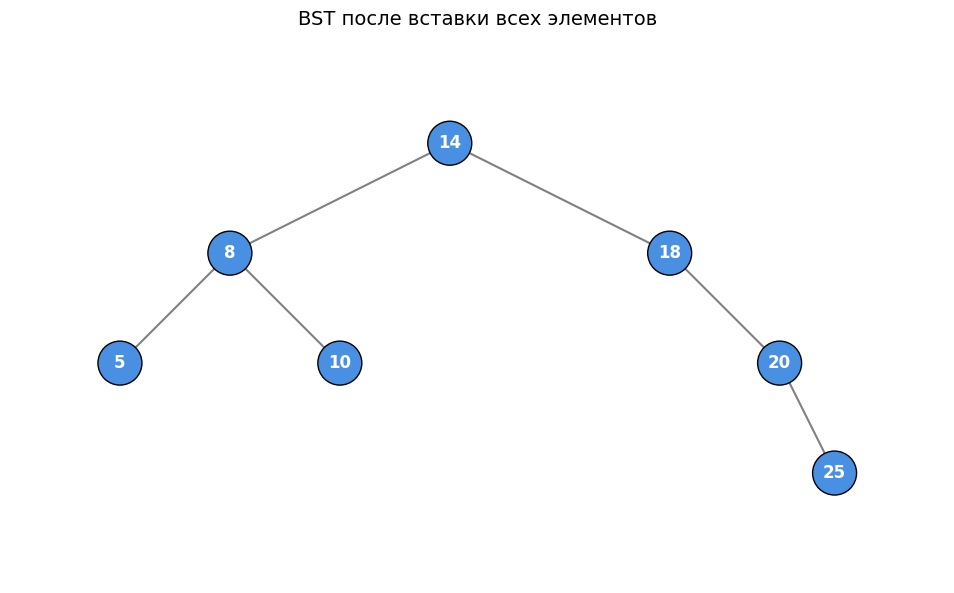

Поиск 8: Найден
Узел со значением 5 удалён.


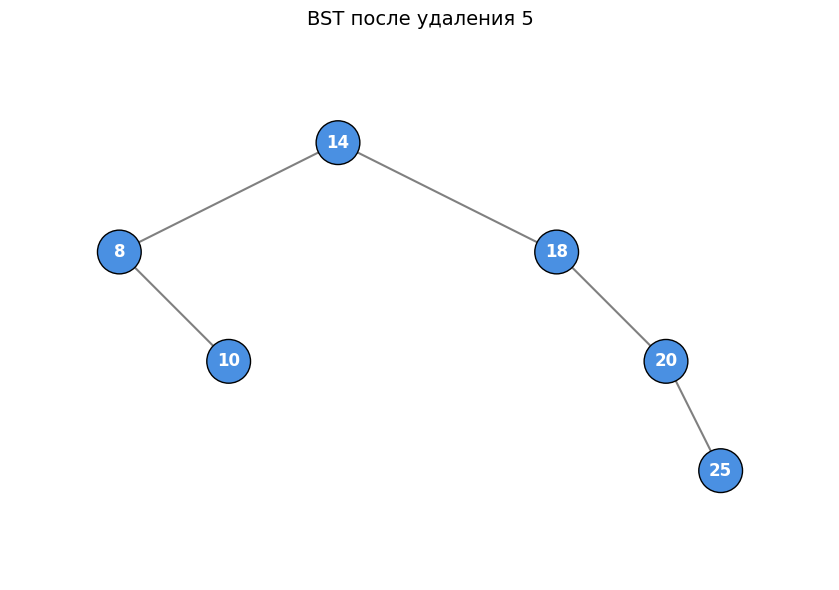


Исходный массив: [14, 8, 18, 5, 10, 20, 25]
Отсортированный массив (Heap Sort): [5, 8, 10, 14, 18, 20, 25]


In [1]:
import matplotlib.pyplot as plt    #для создания окна с графиком и отрисовки дерева (узлы, рёбра, оси)
import matplotlib.patches as mpatches    #для рисования кругов (узлов дерева) с заданными цветом и размером


# 1. ГРАФ: матрицы смежности и инцидентности, компоненты связности

def generate_matrix(n, edges):    # функция построения матриц
    A = [[0] * n for _ in range(n)]          # матрица смежности
    m = len(edges)
    inc = [[0] * m for _ in range(n)]         # матрица инцидентности

    for idx, (i, j) in enumerate(edges):   # проходим по всем рёбрам с их индексами
        u = i - 1    # переводим вершину i в 0-индексацию
        v = j - 1    # переводим вершину j в 0-индексацию
        # смежность
        A[u][v] = 1   # ставим 1 на пересечении u и v
        A[v][u] = 1
        # инцидентность
        inc[u][idx] = 1   # в столбце idx ставим 1 в строке u
        inc[v][idx] = 1

    return A, inc


def components_from_adj_matrix(A):   # поиск компонента связности с помощью BFS
    n = len(A)    # число вершин
    visited = [False] * n    # список посещённых вершин
    components = []    # список для хранения найденных компонент

    def bfs(start):    # функция обхода в ширину от стартовой вершины
        queue = [start]    # создаём очередь с начальной вершиной
        visited[start] = True
        comp = []     # список для сбора вершин текущей компоненты
        while queue:    # пока очередь не пуста
            v = queue.pop(0)
            comp.append(v + 1)   # добавляем вершину в компоненту (перевод в 1-нумерацию)
            for u in range(n):   # перебираем все вершины графа
                if A[v][u] == 1 and not visited[u]:
                    visited[u] = True
                    queue.append(u)   # добавляем u в конец очереди
        return comp    # возвращаем собранную компоненту

    for i in range(n):   # проходим по всем вершинам
        if not visited[i]:
            components.append(bfs(i))    # запускаем BFS и добавляем новую компоненту

    return components


# 2. БИНАРНОЕ ДЕРЕВО ПОИСКА (BST)

class Node:    # класс узла дерева
    def __init__(self, key):   # конструктор принимает ключ
        self.key = key    # сохраняем ключ
        self.left = None
        self.right = None


class BST:   # класс бинарного дерева поиска
    def __init__(self):
        self.root = None

    def insert(self, key):    # публичный метод вставки ключа
        if self.root is None:
            self.root = Node(key)   # создаём корень с этим ключом
        else:
            self._insert_recursive(self.root, key)    # вызываем рекурсивную вставку от корня

    def _insert_recursive(self, node, key):   # рекурсивная вставка
        if key < node.key:
            if node.left is None:
                node.left = Node(key)
            else:
                self._insert_recursive(node.left, key)
        elif key > node.key:
            if node.right is None:
                node.right = Node(key)
            else:
                self._insert_recursive(node.right, key)    # рекурсивно идём вправо
        # равные ключи не вставляем

    def search(self, key):    # публичный метод поиска ключа
        return self._search_recursive(self.root, key)    # запускаем рекурсивный поиск от корня

    def _search_recursive(self, node, key):   # рекурсивный поиск
        if node is None or node.key == key:
            return node
        if key < node.key:
            return self._search_recursive(node.left, key)
        return self._search_recursive(node.right, key)

    def delete(self, key):    # публичный метод удаления
        self.root = self._delete_recursive(self.root, key)   # запускаем рекурсивное удаление, обновляем корень

    def _delete_recursive(self, node, key):   # рекурсивное удаление
        if node is None:
            return None
        if key < node.key:
            node.left = self._delete_recursive(node.left, key)
        elif key > node.key:
            node.right = self._delete_recursive(node.right, key)
        else:
            # узел найден
            if node.left is None:
                return node.right
            elif node.right is None:
                return node.left
            # два потомка: заменяем наименьшим из правого поддерева
            temp = self._min_value_node(node.right)
            node.key = temp.key
            node.right = self._delete_recursive(node.right, temp.key)
        return node    # возвращаем (возможно изменённый) узел

    def _min_value_node(self, node):    # поиск узла с минимальным ключом в поддереве
        current = node
        while current.left:
            current = current.left
        return current   # возвращаем найденный узел


# ВИЗУАЛИЗАЦИЯ ДЕРЕВА
def visualize_bst(bst, title="Бинарное дерево поиска"):
    """Визуализация BST с помощью matplotlib."""
    if bst.root is None:
        print("Дерево пусто.")
        return

    # рекурсивное назначение координат
    pos = {}   # словарь для хранения координат узлов
    def assign_positions(node, x=0, y=0, dx=4, dy=2):    # рекурсивное назначение координат
        if node is None:
            return
        pos[node.key] = (x, y)    # сохраняем координаты для текущего узла
        # левый потомок: смещаем влево-вниз, уменьшаем горизонтальный шаг вдвое
        assign_positions(node.left, x - dx, y - dy, dx / 2, dy)
        # правый потомок: смещаем вправо-вниз
        assign_positions(node.right, x + dx, y - dy, dx / 2, dy)

    assign_positions(bst.root)   # начинаем расстановку от корня

    fig, ax = plt.subplots(figsize=(10, 6))   # создаём окно и оси размером 10x6 дюймов
    ax.set_aspect('equal')   # делаем равные масштабы по осям

    # рисуем рёбра
    def draw_edges(node):
        if node is None:
            return
        if node.left:
            x1, y1 = pos[node.key]   # координаты текущего узла
            x2, y2 = pos[node.left.key]    # координаты левого потомка
            ax.plot([x1, x2], [y1, y2], color='gray', zorder=1, linewidth=1.5)    # рисуем линию
            draw_edges(node.left)   # рекурсивно рисуем рёбра в левом поддер
        if node.right:
            x1, y1 = pos[node.key]
            x2, y2 = pos[node.right.key]
            ax.plot([x1, x2], [y1, y2], color='gray', zorder=1, linewidth=1.5)
            draw_edges(node.right)   # рекурсивно рисуем рёбра в правом поддереве

    draw_edges(bst.root)   # начинаем рисование рёбер от корня

    # рисуем узлы
    for key, (x, y) in pos.items():   # проходим по всем узлам
        circle = mpatches.Circle((x, y), radius=0.4, facecolor='#4A90E2',
                                 edgecolor='black', zorder=2)   # создаём синий круг
        ax.add_patch(circle)   # добавляем круг на оси
        ax.text(x, y, str(key), ha='center', va='center', fontsize=12,
                fontweight='bold', color='white', zorder=3)    # добавляем текст (ключ) поверх круга

    # Устанавливаем границы графика с небольшим запасом
    xs = [x for x, _ in pos.values()]   # все координаты X
    ys = [y for _, y in pos.values()]   # все координаты Y
    ax.set_xlim(min(xs) - 2, max(xs) + 2)
    ax.set_ylim(min(ys) - 2, max(ys) + 2)
    ax.axis('off')   # отключаем оси и сетку
    plt.title(title, fontsize=14)   # устанавливаем заголовок
    plt.tight_layout()    # автоматически подгоняем расположение
    plt.show()



# 3. ПИРАМИДАЛЬНАЯ СОРТИРОВКА (HEAP SORT)

def heapify(arr, n, i):
    """Восстановление свойств max-кучи на поддереве с корнем i."""
    largest = i   # считаем корень максимальным числом
    # индексы потомков
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left
    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)   # рекурсивно восстанавливаем кучу для затронутого поддерева


def heap_sort(arr):
    """Сортировка массива по возрастанию"""
    n = len(arr)
    # построение max-кучи
    for i in range(n // 2 - 1, -1, -1):   # идём от последнего родителя к корню
        heapify(arr, n, i)   # превращаем поддерево в кучу
    # извлечение элементов
    for i in range(n - 1, 0, -1):  # идём от конца к началу
        arr[i], arr[0] = arr[0], arr[i]   # меняем корень (максимум) с элементом на позиции i
        heapify(arr, i, 0)   #восстанавливаем кучу для уменьшенного размера
    return arr



# 4. ЗАПУСК

if __name__ == "__main__":

    # ----- ГРАФ -----
    n_vertices = 7
    edges = [(1, 2), (1, 3), (2, 4), (3, 5), (4, 6), (6, 7)]
    A, inc = generate_matrix(n_vertices, edges)

    print("\nМатрица смежности (7x7):")
    for row in A:
        print(row)

    print("\nМатрица инцидентности (7x6):")
    for row in inc:
        print(row)

    components = components_from_adj_matrix(A)
    print(f"\nКомпоненты связности: {components}")
    print("(Граф связный, одна компонента)\n")

    # ----- BST -----
    elements = [14, 8, 18, 5, 10, 20, 25]
    bst = BST()   # создаём дерево
    for e in elements:   # вставляем элементы по одному
        bst.insert(e)
    print(f"Вставлены элементы: {elements}")
    visualize_bst(bst, title="BST после вставки всех элементов")

    # Поиск 8
    found = bst.search(8)
    print(f"Поиск 8: {'Найден' if found else 'Не найден'}")

    # Удаление 5
    bst.delete(5)
    print("Узел со значением 5 удалён.")
    visualize_bst(bst, title="BST после удаления 5")

    # ----- HEAP SORT -----
    arr = [14, 8, 18, 5, 10, 20, 25]
    print(f"\nИсходный массив: {arr}")
    sorted_arr = heap_sort(arr.copy())   # копия, чтобы не менять оригинал
    print(f"Отсортированный массив (Heap Sort): {sorted_arr}")